In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import learning_curve

df = pd.read_csv('loan_data.csv')
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [2]:
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [3]:
numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [4]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
tree_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
tree_gini.fit(X_train, y_train)
tree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_
print(f"Лучшие параметры: {grid_search.best_params_}")

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


Accuracy: 0.918
Precision: 0.882
Recall: 0.730
F1-Score: 0.799
Confusion Matrix:
[[6804  196]
 [ 540 1460]]


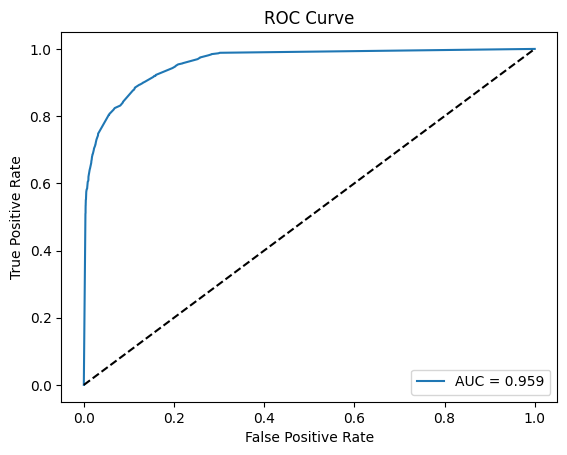

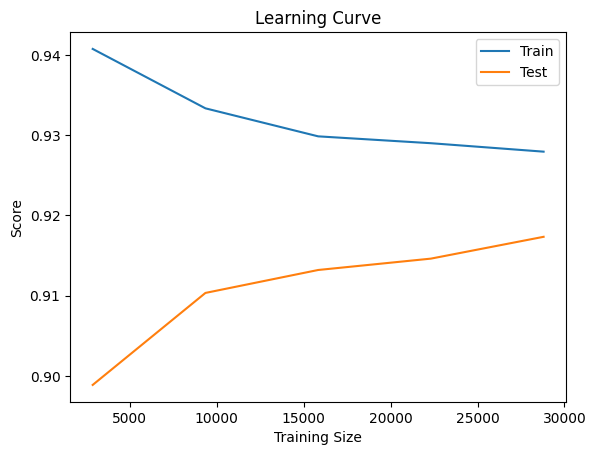

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"Confusion Matrix:\n{cm}")
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
    train_sizes, train_scores, test_scores = learning_curve(model, X_train, y_train, cv=5)
    plt.figure()
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Test')
    plt.xlabel('Training Size')
    plt.ylabel('Score')
    plt.title('Learning Curve')
    plt.legend()
    plt.show()
evaluate_model(best_tree, X_test, y_test)

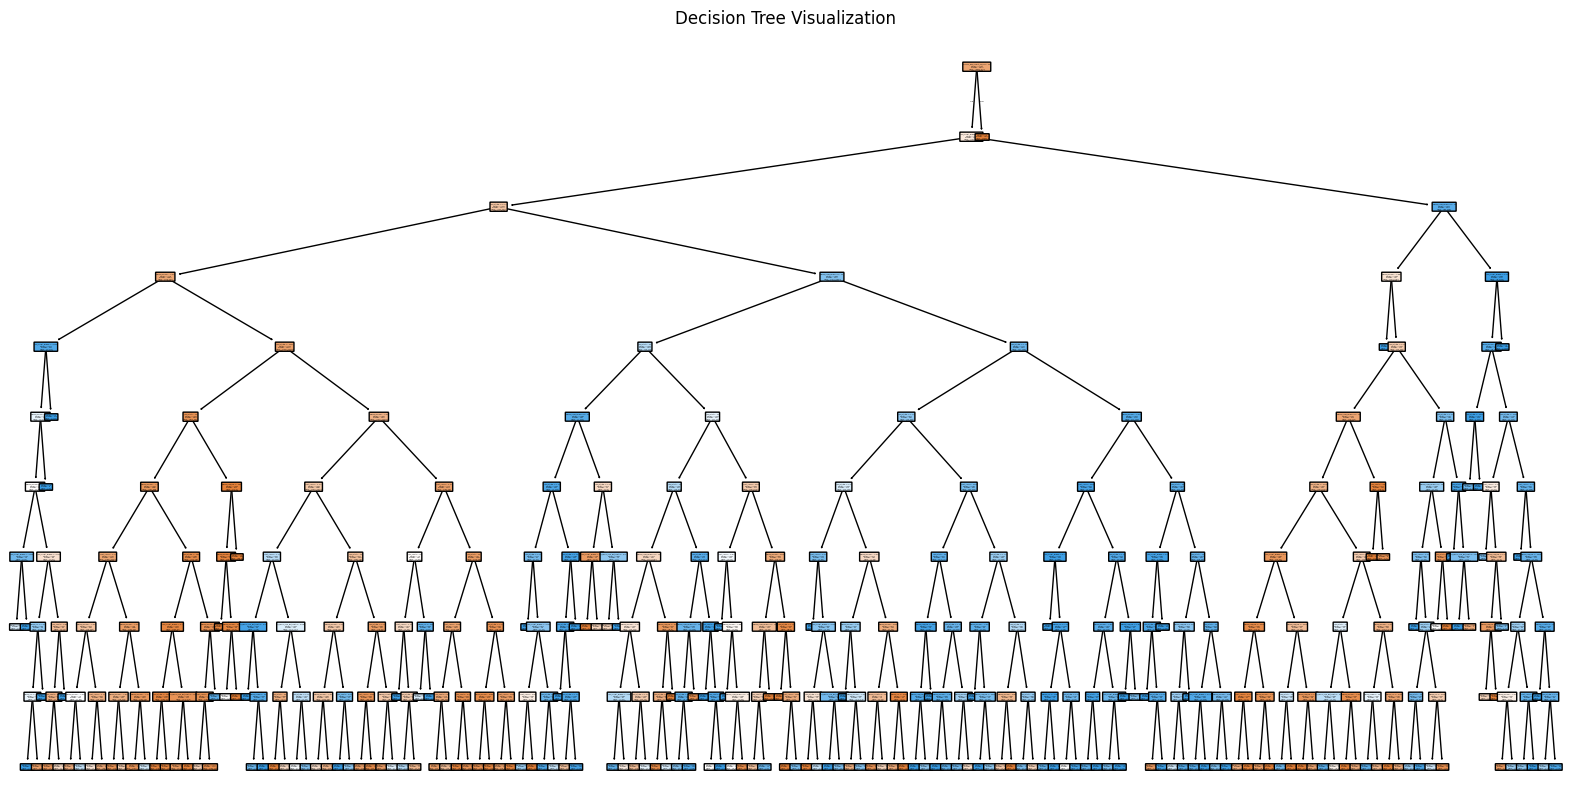

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(best_tree, feature_names=X.columns, class_names=['Rejected', 'Approved'], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

Начинаем подбор параметров...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучшие параметры: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
Дообучение на полных данных...
Accuracy: 0.927
Precision: 0.888
Recall: 0.771
F1-Score: 0.825
Confusion Matrix:
[[6805  195]
 [ 458 1542]]


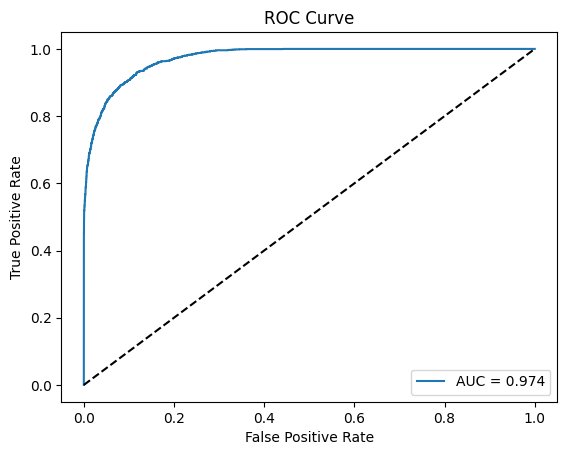

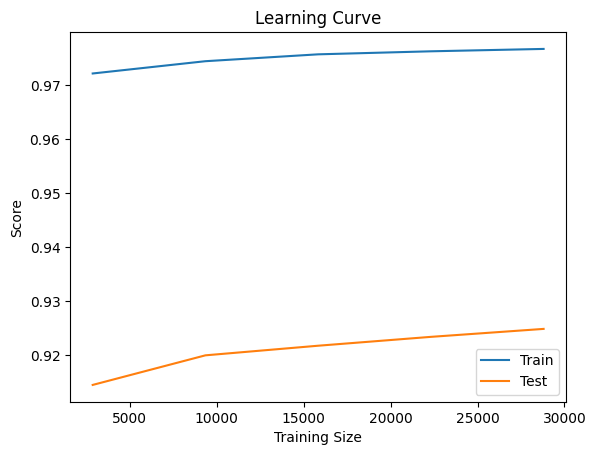

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV

X_small, _, y_small, _ = train_test_split(
    X_train, y_train, train_size=0.3, stratify=y_train, random_state=42
)
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [1, 5, 10],
}
random_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    param_dist,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=2
)
random_search.fit(X_small, y_small)
best_rf = random_search.best_estimator_
print(f"Лучшие параметры: {random_search.best_params_}")
best_rf.fit(X_train, y_train)
evaluate_model(best_rf, X_test, y_test)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np
sample_size = int(0.3 * len(X_train))
indices = np.random.choice(len(X_train), sample_size, replace=False)
X_small = X_train.iloc[indices]
y_small = y_train.iloc[indices]
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_small, y_small)
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
param_dist_xgb = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}
random_search_xgb = RandomizedSearchCV(
    xgb_base,
    param_dist_xgb,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search_xgb.fit(X_small, y_small)
best_xgb = random_search_xgb.best_estimator_
gb.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)
print(f"Лучшие параметры XGBoost: {random_search_xgb.best_params_}")

Размер выборки для подбора параметров: (10800, 13)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Дообучение на полных данных...
Обучение завершено!
Лучшие параметры XGBoost: {'colsample_bytree': np.float64(0.7428600453765822), 'learning_rate': np.float64(0.20526654188465587), 'max_depth': 7, 'n_estimators': 51, 'subsample': np.float64(0.9165996316800473)}


In [ ]:
n_range = [50, 100, 150, 200]
f1_scores = []
for n in n_range:
    model = XGBClassifier(n_estimators=n, learning_rate=0.1, random_state=42)
    model.fit(X_small, y_small)
    f1_scores.append(f1_score(y_small, model.predict(X_small)))
lr_range = [0.01, 0.05, 0.1, 0.2, 0.3]
f1_scores_lr = []
for lr in lr_range:
    model = XGBClassifier(n_estimators=100, learning_rate=lr, random_state=42)
    model.fit(X_small, y_small)
    f1_scores_lr.append(f1_score(y_small, model.predict(X_small)))

  n_estimators=50: Train F1=0.8288, Test F1=0.8092
  n_estimators=100: Train F1=0.8677, Test F1=0.8247
  n_estimators=150: Train F1=0.8954, Test F1=0.8285
  n_estimators=200: Train F1=0.9179, Test F1=0.8295
  n_estimators=250: Train F1=0.9375, Test F1=0.8312
  n_estimators=300: Train F1=0.9513, Test F1=0.8298


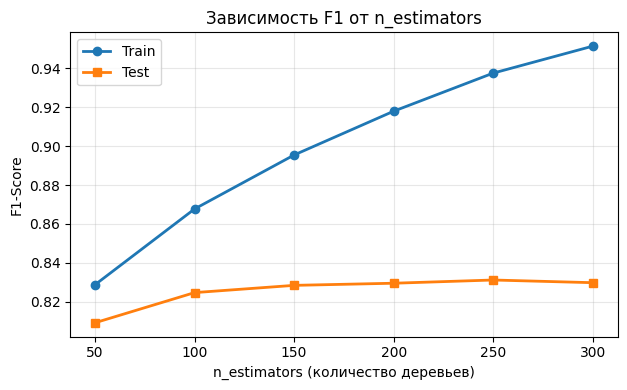

In [ ]:
X_analysis = X_train.iloc[indices]
y_analysis = y_train.iloc[indices]

n_range = [50, 100, 150, 200, 250, 300]
train_scores = []
test_scores = []

for n in n_range:
    model = XGBClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_analysis, y_analysis)
    y_pred_train = model.predict(X_analysis)
    train_f1 = f1_score(y_analysis, y_pred_train)
    train_scores.append(train_f1)
    y_pred_test = model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_scores.append(test_f1)
    print(f"  n_estimators={n}: Train F1={train_f1:.4f}, Test F1={test_f1:.4f}")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(n_range, train_scores, marker='o', label='Train', linewidth=2)
plt.plot(n_range, test_scores, marker='s', label='Test', linewidth=2)
plt.xlabel('n_estimators (количество деревьев)')
plt.ylabel('F1-Score')
plt.title('Зависимость F1 от n_estimators')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

sample_size = min(5000, len(X_train))
indices = np.random.choice(len(X_train), sample_size, replace=False)
X_small = X_train.iloc[indices]
y_small = y_train.iloc[indices]
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    )),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        probability=True,
        random_state=42
    )),
    ('lr', LogisticRegression(
        max_iter=500,
        random_state=42
    )),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]
meta_model = LogisticRegression(max_iter=1000, random_state=42)
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1
)
stacking.fit(X_small, y_small)
y_pred_stacking = stacking.predict(X_test)
print("Результаты Stacking")
print(f"Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_stacking):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_stacking):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_stacking):.4f}")

=== Результаты Stacking ===
Accuracy: 0.9156
F1-Score: 0.7996
Precision: 0.8460
Recall: 0.7580


In [25]:
# 8. Сравниваем все модели
import pandas as pd

# Создаём функцию для быстрой оценки
def quick_eval(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }

# Собираем все модели
all_models = [
    ('Decision Tree', best_tree),  # из задания 1
    ('Random Forest', best_rf),    # из задания 2
    ('Gradient Boosting', gb),     # из задания 3
    ('XGBoost', best_xgb),         # из задания 3
    ('Stacking', stacking)         # текущее задание
]

# Создаём таблицу результатов
results = []
for name, model in all_models:
    try:
        results.append(quick_eval(name, model, X_test, y_test))
    except:
        print(f"Пропускаем {name} - модель не обучена")

# Преобразуем в DataFrame
results_df = pd.DataFrame(results)
print("\n=== Сравнение всех моделей ===")
print(results_df.sort_values('F1', ascending=False).to_string(index=False))

# 9. Вывод
print("\n=== Вывод ===")
best_model = results_df.loc[results_df['F1'].idxmax()]
print(f"Наиболее подходящий алгоритм: {best_model['Model']}")
print(f"Лучший F1-Score: {best_model['F1']:.4f}")
print(f"Обоснование: Данный алгоритм показал наилучший баланс между точностью и полнотой.")


=== Сравнение всех моделей ===
            Model  Accuracy       F1  Precision  Recall
          XGBoost  0.932444 0.838039   0.896807  0.7865
    Random Forest  0.927444 0.825261   0.887737  0.7710
Gradient Boosting  0.922000 0.812099   0.873848  0.7585
         Stacking  0.915556 0.799578   0.845982  0.7580
    Decision Tree  0.918222 0.798687   0.881643  0.7300

=== Вывод ===
Наиболее подходящий алгоритм: XGBoost
Лучший F1-Score: 0.8380
Обоснование: Данный алгоритм показал наилучший баланс между точностью и полнотой.
